# GAN

In [48]:
%pip install torchvision

Note: you may need to restart the kernel to use updated packages.


In [1]:
import torch
import os
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from PIL import Image

In [31]:
class ImageProcessor:
    def __init__(self, root_dir_path, transformation=None):
        self.root_dir_path = root_dir_path
        self.transformation = transformation

        self.all_image_paths = [os.path.join(root_dir_path,img) for img in os.listdir(root_dir_path)]

    def __len__(self):
        return len(self.all_image_paths)
    
    def __getitem__(self,idx):
        image_path = self.all_image_paths[idx]
        image = Image.open(image_path).convert('RGB')

        if self.transformation:
            image = self.transformation(image)

        return image



In [32]:
root_dir_path = "img_align_celeba"

transformation = transforms.Compose([
    transforms.CenterCrop(178),    # 178*218 => 178*178
    transforms.Resize(64),
    transforms.ToTensor(),
    transforms.Normalize([0.5,0.5,0.5],[0.5,0.5,0.5])
])

In [33]:
dataset = ImageProcessor(root_dir_path, transformation)
print(f"Total no of images: {len(dataset)}")

Total no of images: 202599


In [34]:
dataloader = DataLoader(dataset,batch_size=128, shuffle = True)

# Generator Network

In [36]:

import torch.nn as nn
import torch.optim as optim
import numpy as np

In [37]:
class Generator(nn.Module):
    def __init__(self,z_dim=100, img_channels=3):
    
        super(Generator,self).__init__()


        self.model = nn.Sequential(
                nn.Linear(z_dim, 256),
                nn.ReLU(),
                nn.Linear(256,512),
                nn.ReLU(),
                nn.Linear(512,1024),
                nn.ReLU(),
                nn.Linear(1024,64*64*img_channels),
                nn.Tanh()
        )

    def forward(self,z):
        img = self.model(z)
        img = img.view(img.size(0),3,64,64)

        return img





# Descriminator Network

In [38]:
class Discriminator(nn.Module):
    def __init__(self,img_channels=3):
        super(Discriminator, self).__init__()
        self.model = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 64 * img_channels, 1024),
            nn.LeakyReLU(0.2,inplace=True),
            nn.Linear(1024, 512),
            nn.LeakyReLU(0.2,inplace=True),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2,inplace=True),
            nn.Linear(256, 1),
            nn.Sigmoid() # Probability of being real
        )

    def forward(self, img):
        return self.model(img) 

In [39]:
GANLoss = nn.BCELoss()
generator = Generator()
discriminator = Discriminator()
g_optimizer = optim.Adam(generator.parameters(), lr=0.0002, betas=(0.5, 0.999))
d_optimizer = optim.Adam(discriminator.parameters(), lr=0.0002, betas=(0.5, 0.999)) 

In [40]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else: 
    device = torch.device("cpu")

print(f"Using device: {device}")


Using device: mps


In [41]:
generator = generator.to(device)
discriminator = discriminator.to(device)


# Training Data


In [50]:
def train(generator,discriminator ,dataloader, epochs=10):
    for epoch in range(epochs):
        for i,imgs in enumerate(dataloader):
            real_imgs = imgs.to(device)
            batch_size = real_imgs.size(0)
            real_labels = torch.ones(batch_size, 1).to(device)
            fake_labels = torch.zeros(batch_size, 1).to(device)
            # discriminator training
            d_optimizer.zero_grad()
            fake_imgs = generator(torch.randn(batch_size, 100).to(device))
            real_loss = GANLoss(discriminator(real_imgs), real_labels) 
            fake_loss = GANLoss(discriminator(fake_imgs.detach()), fake_labels)
            d_loss = real_loss + fake_loss
            d_loss.backward()
            d_optimizer.step()

            # generator training
            g_optimizer.zero_grad()
            g_loss = GANLoss(discriminator(fake_imgs), real_labels)
            g_loss.backward()
            g_optimizer.step()

            if i % 50 ==0:
                print(f"Epoch {epoch+1}/{epochs}, Step {i+1}/{len(dataloader)}, D Loss: {d_loss.item():.4f}, G Loss: {g_loss.item():.4f}")

        save_generated_images(generator,epoch+1,device)


In [49]:
import matplotlib.pyplot as plt
import torchvision

def save_generated_images(generator, epoch, device, num_images=8):
    
    
    z = torch.randn(num_images, 100).to(device)
    generated_imgs = generator(z).detach().cpu()
    
    grid =torchvision.utils.make_grid(generated_imgs, nrow=4, normalize=True)
    plt.imshow(np.transpose(grid,(1,2,0)))  # (channel , height , width) => (height,width , channel) shuffle the dimensions for plt.imshow
    plt.title(f"Generated Images at Epoch {epoch}")
    plt.axis('off')
    plt.show()

    

Epoch 1/10, Step 1/1583, D Loss: 0.7149, G Loss: 2.3114
Epoch 1/10, Step 51/1583, D Loss: 0.8161, G Loss: 2.0686
Epoch 1/10, Step 101/1583, D Loss: 0.8781, G Loss: 2.4765
Epoch 1/10, Step 151/1583, D Loss: 0.7092, G Loss: 2.2134
Epoch 1/10, Step 201/1583, D Loss: 0.9819, G Loss: 2.1678
Epoch 1/10, Step 251/1583, D Loss: 0.8191, G Loss: 2.5008
Epoch 1/10, Step 301/1583, D Loss: 1.0115, G Loss: 4.0229
Epoch 1/10, Step 351/1583, D Loss: 0.7860, G Loss: 2.0728
Epoch 1/10, Step 401/1583, D Loss: 0.6864, G Loss: 2.1760
Epoch 1/10, Step 451/1583, D Loss: 1.0447, G Loss: 1.8400
Epoch 1/10, Step 501/1583, D Loss: 0.8104, G Loss: 2.2595
Epoch 1/10, Step 551/1583, D Loss: 0.7940, G Loss: 2.3819
Epoch 1/10, Step 601/1583, D Loss: 0.7184, G Loss: 1.6733
Epoch 1/10, Step 651/1583, D Loss: 0.8027, G Loss: 2.9890
Epoch 1/10, Step 701/1583, D Loss: 0.8811, G Loss: 1.7861
Epoch 1/10, Step 751/1583, D Loss: 0.8308, G Loss: 2.4938
Epoch 1/10, Step 801/1583, D Loss: 0.9507, G Loss: 2.1148
Epoch 1/10, Step 

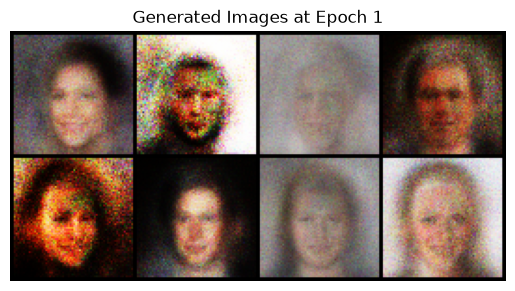

Epoch 2/10, Step 1/1583, D Loss: 1.0183, G Loss: 2.4447
Epoch 2/10, Step 51/1583, D Loss: 0.9355, G Loss: 1.9137
Epoch 2/10, Step 101/1583, D Loss: 0.9306, G Loss: 1.7708
Epoch 2/10, Step 151/1583, D Loss: 1.0364, G Loss: 1.7781
Epoch 2/10, Step 201/1583, D Loss: 0.8847, G Loss: 2.1055
Epoch 2/10, Step 251/1583, D Loss: 0.7388, G Loss: 1.7701
Epoch 2/10, Step 301/1583, D Loss: 0.9354, G Loss: 1.6272
Epoch 2/10, Step 351/1583, D Loss: 0.9326, G Loss: 1.9998
Epoch 2/10, Step 401/1583, D Loss: 0.9324, G Loss: 1.6914
Epoch 2/10, Step 451/1583, D Loss: 1.1422, G Loss: 1.5907
Epoch 2/10, Step 501/1583, D Loss: 0.8905, G Loss: 1.7510
Epoch 2/10, Step 551/1583, D Loss: 0.9565, G Loss: 1.9886
Epoch 2/10, Step 601/1583, D Loss: 0.9431, G Loss: 1.9442
Epoch 2/10, Step 651/1583, D Loss: 0.9031, G Loss: 1.9101
Epoch 2/10, Step 701/1583, D Loss: 1.0983, G Loss: 2.0266
Epoch 2/10, Step 751/1583, D Loss: 1.0314, G Loss: 1.7252
Epoch 2/10, Step 801/1583, D Loss: 1.0124, G Loss: 2.0265
Epoch 2/10, Step 

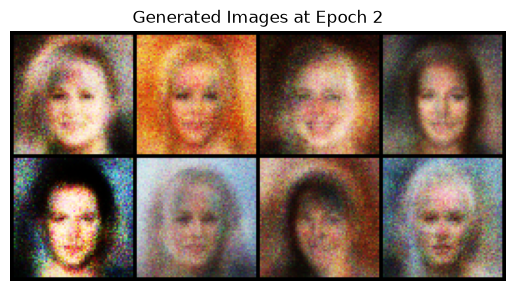

Epoch 3/10, Step 1/1583, D Loss: 1.0564, G Loss: 1.6314
Epoch 3/10, Step 51/1583, D Loss: 1.0732, G Loss: 1.5286
Epoch 3/10, Step 101/1583, D Loss: 0.8750, G Loss: 2.1362
Epoch 3/10, Step 151/1583, D Loss: 0.9913, G Loss: 1.5453
Epoch 3/10, Step 201/1583, D Loss: 0.9632, G Loss: 1.9480
Epoch 3/10, Step 251/1583, D Loss: 1.0191, G Loss: 1.5728
Epoch 3/10, Step 301/1583, D Loss: 1.0264, G Loss: 1.6451
Epoch 3/10, Step 351/1583, D Loss: 0.8446, G Loss: 1.9301
Epoch 3/10, Step 401/1583, D Loss: 1.0625, G Loss: 1.7698
Epoch 3/10, Step 451/1583, D Loss: 0.8573, G Loss: 2.0574
Epoch 3/10, Step 501/1583, D Loss: 0.9635, G Loss: 1.9701
Epoch 3/10, Step 551/1583, D Loss: 0.9605, G Loss: 1.9259
Epoch 3/10, Step 601/1583, D Loss: 1.0881, G Loss: 1.5582
Epoch 3/10, Step 651/1583, D Loss: 0.9092, G Loss: 1.6218
Epoch 3/10, Step 701/1583, D Loss: 1.1231, G Loss: 1.5061
Epoch 3/10, Step 751/1583, D Loss: 0.9756, G Loss: 1.7441
Epoch 3/10, Step 801/1583, D Loss: 1.0249, G Loss: 1.7774
Epoch 3/10, Step 

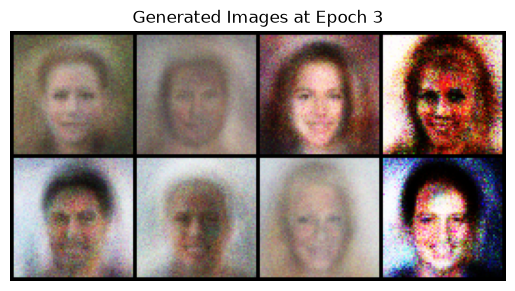

Epoch 4/10, Step 1/1583, D Loss: 1.0489, G Loss: 1.5762
Epoch 4/10, Step 51/1583, D Loss: 0.9831, G Loss: 1.6115
Epoch 4/10, Step 101/1583, D Loss: 1.0919, G Loss: 1.4697
Epoch 4/10, Step 151/1583, D Loss: 0.9550, G Loss: 1.6923
Epoch 4/10, Step 201/1583, D Loss: 1.0839, G Loss: 1.6078
Epoch 4/10, Step 251/1583, D Loss: 1.0213, G Loss: 1.8358
Epoch 4/10, Step 301/1583, D Loss: 1.0181, G Loss: 1.5372
Epoch 4/10, Step 351/1583, D Loss: 1.0177, G Loss: 1.4646
Epoch 4/10, Step 401/1583, D Loss: 0.9161, G Loss: 1.6005
Epoch 4/10, Step 451/1583, D Loss: 0.9988, G Loss: 1.4694
Epoch 4/10, Step 501/1583, D Loss: 0.9902, G Loss: 1.7238
Epoch 4/10, Step 551/1583, D Loss: 1.0900, G Loss: 1.6148
Epoch 4/10, Step 601/1583, D Loss: 1.1736, G Loss: 1.4310
Epoch 4/10, Step 651/1583, D Loss: 1.0114, G Loss: 1.7887
Epoch 4/10, Step 701/1583, D Loss: 0.9646, G Loss: 1.7543
Epoch 4/10, Step 751/1583, D Loss: 0.9319, G Loss: 1.6395
Epoch 4/10, Step 801/1583, D Loss: 1.1450, G Loss: 1.5640
Epoch 4/10, Step 

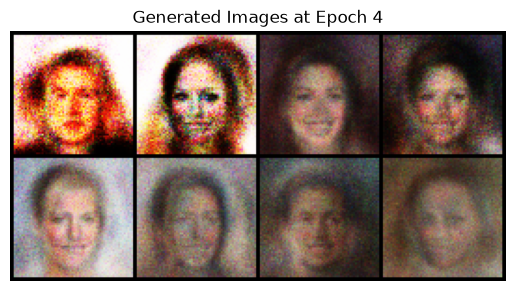

Epoch 5/10, Step 1/1583, D Loss: 1.0177, G Loss: 1.6138
Epoch 5/10, Step 51/1583, D Loss: 1.0876, G Loss: 1.5519
Epoch 5/10, Step 101/1583, D Loss: 1.0169, G Loss: 1.5577
Epoch 5/10, Step 151/1583, D Loss: 1.0294, G Loss: 1.5489
Epoch 5/10, Step 201/1583, D Loss: 1.2249, G Loss: 1.4674
Epoch 5/10, Step 251/1583, D Loss: 1.2095, G Loss: 1.6526
Epoch 5/10, Step 301/1583, D Loss: 0.9487, G Loss: 1.5645
Epoch 5/10, Step 351/1583, D Loss: 1.2408, G Loss: 1.5330
Epoch 5/10, Step 401/1583, D Loss: 0.9740, G Loss: 1.5369
Epoch 5/10, Step 451/1583, D Loss: 1.1421, G Loss: 1.5351
Epoch 5/10, Step 501/1583, D Loss: 1.0924, G Loss: 1.5291
Epoch 5/10, Step 551/1583, D Loss: 1.0313, G Loss: 1.4182
Epoch 5/10, Step 601/1583, D Loss: 1.0853, G Loss: 1.1899
Epoch 5/10, Step 651/1583, D Loss: 0.9585, G Loss: 1.6041
Epoch 5/10, Step 701/1583, D Loss: 1.1386, G Loss: 1.6394
Epoch 5/10, Step 751/1583, D Loss: 1.1103, G Loss: 1.5565
Epoch 5/10, Step 801/1583, D Loss: 1.1253, G Loss: 1.4150
Epoch 5/10, Step 

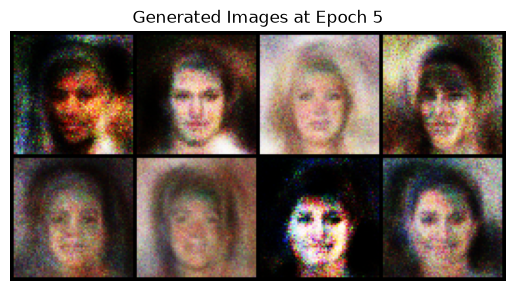

Epoch 6/10, Step 1/1583, D Loss: 0.9567, G Loss: 1.5304
Epoch 6/10, Step 51/1583, D Loss: 1.1318, G Loss: 1.6128
Epoch 6/10, Step 101/1583, D Loss: 1.0183, G Loss: 1.4251
Epoch 6/10, Step 151/1583, D Loss: 1.1341, G Loss: 1.4289
Epoch 6/10, Step 201/1583, D Loss: 1.1327, G Loss: 1.5347
Epoch 6/10, Step 251/1583, D Loss: 1.1522, G Loss: 1.3296
Epoch 6/10, Step 301/1583, D Loss: 1.0682, G Loss: 1.4855
Epoch 6/10, Step 351/1583, D Loss: 1.0660, G Loss: 1.4115
Epoch 6/10, Step 401/1583, D Loss: 1.1036, G Loss: 1.7078
Epoch 6/10, Step 451/1583, D Loss: 1.0804, G Loss: 1.4663
Epoch 6/10, Step 501/1583, D Loss: 1.2057, G Loss: 1.6845
Epoch 6/10, Step 551/1583, D Loss: 1.2168, G Loss: 1.2846
Epoch 6/10, Step 601/1583, D Loss: 1.1194, G Loss: 1.4343
Epoch 6/10, Step 651/1583, D Loss: 1.1483, G Loss: 1.4412
Epoch 6/10, Step 701/1583, D Loss: 0.9838, G Loss: 1.4197
Epoch 6/10, Step 751/1583, D Loss: 1.0614, G Loss: 1.4055
Epoch 6/10, Step 801/1583, D Loss: 1.2514, G Loss: 1.3254
Epoch 6/10, Step 

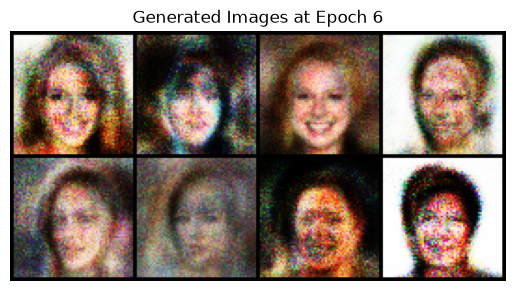

Epoch 7/10, Step 1/1583, D Loss: 1.0813, G Loss: 1.5813
Epoch 7/10, Step 51/1583, D Loss: 1.1382, G Loss: 1.3118
Epoch 7/10, Step 101/1583, D Loss: 1.2600, G Loss: 1.2929
Epoch 7/10, Step 151/1583, D Loss: 1.1289, G Loss: 1.5000
Epoch 7/10, Step 201/1583, D Loss: 1.1125, G Loss: 1.4427
Epoch 7/10, Step 251/1583, D Loss: 0.9676, G Loss: 1.5704
Epoch 7/10, Step 301/1583, D Loss: 1.2451, G Loss: 1.2986
Epoch 7/10, Step 351/1583, D Loss: 1.1150, G Loss: 1.3570
Epoch 7/10, Step 401/1583, D Loss: 1.1421, G Loss: 1.3661
Epoch 7/10, Step 451/1583, D Loss: 1.1895, G Loss: 1.2247
Epoch 7/10, Step 501/1583, D Loss: 1.0677, G Loss: 1.4654
Epoch 7/10, Step 551/1583, D Loss: 1.1013, G Loss: 1.3125
Epoch 7/10, Step 601/1583, D Loss: 1.2054, G Loss: 1.4929
Epoch 7/10, Step 651/1583, D Loss: 1.1249, G Loss: 1.4904
Epoch 7/10, Step 701/1583, D Loss: 1.1330, G Loss: 1.3278
Epoch 7/10, Step 751/1583, D Loss: 1.1955, G Loss: 1.4364
Epoch 7/10, Step 801/1583, D Loss: 1.2001, G Loss: 1.2915
Epoch 7/10, Step 

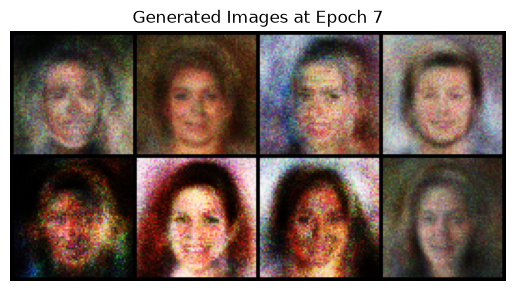

Epoch 8/10, Step 1/1583, D Loss: 1.0910, G Loss: 1.1646
Epoch 8/10, Step 51/1583, D Loss: 1.1659, G Loss: 1.4465
Epoch 8/10, Step 101/1583, D Loss: 1.1606, G Loss: 1.3947
Epoch 8/10, Step 151/1583, D Loss: 1.1241, G Loss: 1.3764
Epoch 8/10, Step 201/1583, D Loss: 1.2138, G Loss: 1.2682
Epoch 8/10, Step 251/1583, D Loss: 1.1289, G Loss: 1.2185
Epoch 8/10, Step 301/1583, D Loss: 1.2060, G Loss: 1.1257
Epoch 8/10, Step 351/1583, D Loss: 1.0931, G Loss: 1.2839
Epoch 8/10, Step 401/1583, D Loss: 1.1490, G Loss: 1.4003
Epoch 8/10, Step 451/1583, D Loss: 1.2127, G Loss: 1.5177
Epoch 8/10, Step 501/1583, D Loss: 1.1954, G Loss: 1.2750
Epoch 8/10, Step 551/1583, D Loss: 1.0904, G Loss: 1.2132
Epoch 8/10, Step 601/1583, D Loss: 1.1779, G Loss: 1.3101
Epoch 8/10, Step 651/1583, D Loss: 1.1139, G Loss: 1.3737
Epoch 8/10, Step 701/1583, D Loss: 1.1799, G Loss: 1.2701
Epoch 8/10, Step 751/1583, D Loss: 1.2795, G Loss: 1.2478
Epoch 8/10, Step 801/1583, D Loss: 1.2716, G Loss: 1.3109
Epoch 8/10, Step 

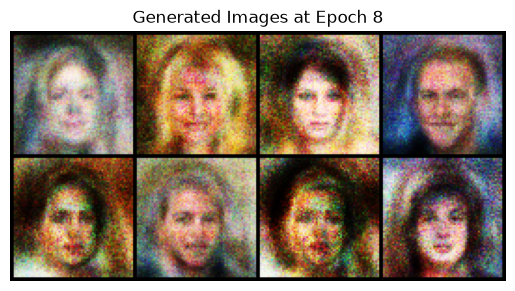

Epoch 9/10, Step 1/1583, D Loss: 1.2355, G Loss: 1.2485
Epoch 9/10, Step 51/1583, D Loss: 1.1565, G Loss: 1.3610
Epoch 9/10, Step 101/1583, D Loss: 1.1613, G Loss: 1.2020
Epoch 9/10, Step 151/1583, D Loss: 1.2275, G Loss: 1.2696
Epoch 9/10, Step 201/1583, D Loss: 1.1729, G Loss: 1.4478
Epoch 9/10, Step 251/1583, D Loss: 1.1604, G Loss: 1.2816
Epoch 9/10, Step 301/1583, D Loss: 1.2704, G Loss: 1.2059
Epoch 9/10, Step 351/1583, D Loss: 1.1233, G Loss: 1.2162
Epoch 9/10, Step 401/1583, D Loss: 1.1246, G Loss: 1.1764
Epoch 9/10, Step 451/1583, D Loss: 1.2595, G Loss: 1.1957
Epoch 9/10, Step 501/1583, D Loss: 1.2186, G Loss: 1.4852
Epoch 9/10, Step 551/1583, D Loss: 1.0784, G Loss: 1.3147
Epoch 9/10, Step 601/1583, D Loss: 1.1488, G Loss: 1.3639
Epoch 9/10, Step 651/1583, D Loss: 1.1538, G Loss: 1.2976
Epoch 9/10, Step 701/1583, D Loss: 1.1047, G Loss: 1.2581
Epoch 9/10, Step 751/1583, D Loss: 1.1573, G Loss: 1.2411
Epoch 9/10, Step 801/1583, D Loss: 1.2364, G Loss: 1.4091
Epoch 9/10, Step 

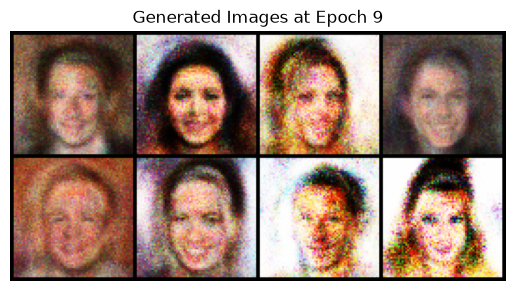

Epoch 10/10, Step 1/1583, D Loss: 1.1807, G Loss: 1.2893
Epoch 10/10, Step 51/1583, D Loss: 1.1487, G Loss: 1.2666
Epoch 10/10, Step 101/1583, D Loss: 1.1418, G Loss: 1.0961
Epoch 10/10, Step 151/1583, D Loss: 1.1712, G Loss: 1.4062
Epoch 10/10, Step 201/1583, D Loss: 1.2138, G Loss: 1.1451
Epoch 10/10, Step 251/1583, D Loss: 1.3251, G Loss: 1.2397
Epoch 10/10, Step 301/1583, D Loss: 1.1015, G Loss: 1.2750
Epoch 10/10, Step 351/1583, D Loss: 1.1103, G Loss: 1.3218
Epoch 10/10, Step 401/1583, D Loss: 1.0600, G Loss: 1.3017
Epoch 10/10, Step 451/1583, D Loss: 1.1599, G Loss: 1.2420
Epoch 10/10, Step 501/1583, D Loss: 1.2305, G Loss: 1.1772
Epoch 10/10, Step 551/1583, D Loss: 1.1551, G Loss: 1.2664
Epoch 10/10, Step 601/1583, D Loss: 1.1688, G Loss: 1.2444
Epoch 10/10, Step 651/1583, D Loss: 1.2227, G Loss: 1.0978
Epoch 10/10, Step 701/1583, D Loss: 1.2136, G Loss: 1.1439
Epoch 10/10, Step 751/1583, D Loss: 1.1577, G Loss: 1.2283
Epoch 10/10, Step 801/1583, D Loss: 1.1712, G Loss: 1.2672


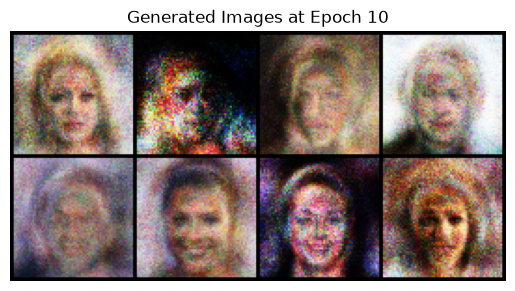

In [51]:
train(generator,discriminator,dataloader,epochs=10)